# Spectral Clustering

**Dataset** : Wine - 178 echantillons, 13 features, 3 classes  
**Objectif** : clustering non supervise avec Spectral Clustering, evaluation via ARI, NMI et Silhouette Score  


Dataset complet: 178 echantillons
Train: 124 | Validation: 27 | Test: 27
Classes reelles: 3
Variance expliquee PCA 2D: 0.549
Variance expliquee PCA 5D: 0.802


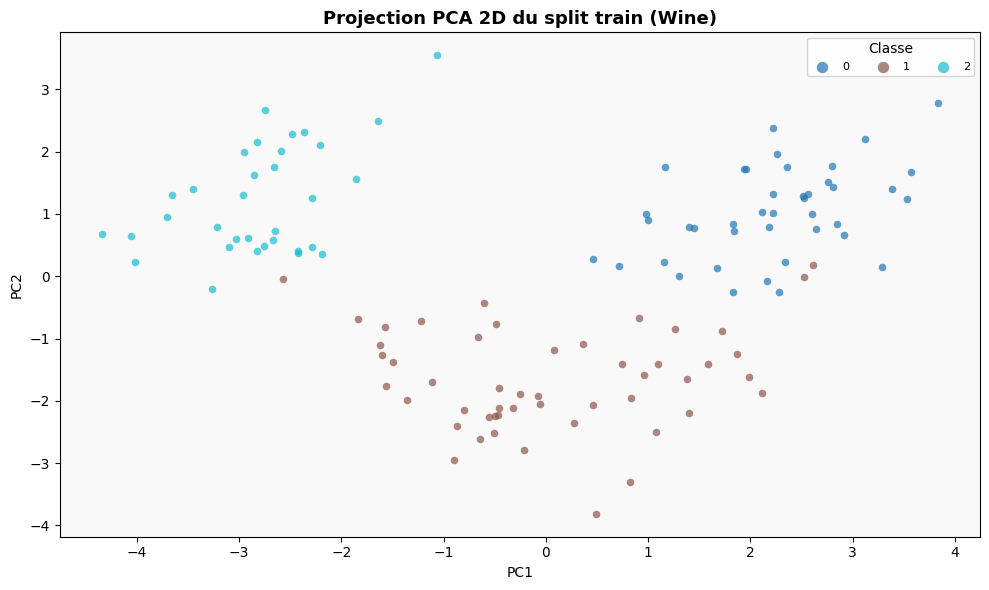

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Chargement des donnees Wine
wine = load_wine()
X = wine.data.astype(float)
y_true = wine.target.astype(int)

# Split train / validation / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_true,
    test_size=0.30,
    stratify=y_true,
    random_state=42,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42,
)

print(f"Dataset complet: {X.shape[0]} echantillons")
print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Classes reelles: {len(np.unique(y_true))}")

# Standardisation sur train uniquement
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# PCA pour clustering et visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)
X_val_pca2 = pca_2d.transform(X_val_scaled)
X_test_pca2 = pca_2d.transform(X_test_scaled)

pca_5d = PCA(n_components=5, random_state=42)
X_train_pca5 = pca_5d.fit_transform(X_train_scaled)
X_val_pca5 = pca_5d.transform(X_val_scaled)
X_test_pca5 = pca_5d.transform(X_test_scaled)

print(f"Variance expliquee PCA 2D: {pca_2d.explained_variance_ratio_.sum():.3f}")
print(f"Variance expliquee PCA 5D: {pca_5d.explained_variance_ratio_.sum():.3f}")

# Visualisation rapide du train en PCA 2D
unique_classes = np.unique(y_train)
colors_true = plt.cm.tab10(np.linspace(0, 1, len(unique_classes)))
label_to_color = {cls: colors_true[i] for i, cls in enumerate(unique_classes)}

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
for cls in unique_classes:
    mask = y_train == cls
    ax.scatter(
        X_train_pca2[mask, 0],
        X_train_pca2[mask, 1],
        c=[label_to_color[cls]],
        label=str(cls),
        s=30,
        alpha=0.7,
        linewidths=0,
    )
ax.set_title('Projection PCA 2D du split train (Wine)', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Classe', ncol=3, fontsize=8, markerscale=1.5, loc='best')
ax.set_facecolor('#f9f9f9')
plt.tight_layout()
plt.show()

In [ ]:
# Tuning Spectral Clustering sur la validation
param_grid = {
    'affinity': ['rbf', 'nearest_neighbors'],
    'gamma': [0.25, 0.5, 1.0, 2.0],
    'n_neighbors': [5, 8, 10],
    'assign_labels': ['kmeans', 'discretize'],
    'n_clusters': [3],
}

ari_min = 0.60
nmi_min = 0.60


def evaluate_clustering(X_eval, y_eval, labels):
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2:
        return {
            'n_clusters': len(unique_labels),
            'ari': np.nan,
            'nmi': np.nan,
            'silhouette': np.nan,
            'valid': False,
        }

    return {
        'n_clusters': len(unique_labels),
        'ari': adjusted_rand_score(y_eval, labels),
        'nmi': normalized_mutual_info_score(y_eval, labels),
        'silhouette': silhouette_score(X_eval, labels),
        'valid': True,
    }


def validation_score(metrics):
    if not metrics['valid']:
        return -1e9, False, 'invalid_metrics'

    if metrics['ari'] < ari_min or metrics['nmi'] < nmi_min:
        soft_score = metrics['ari'] + metrics['nmi']
        return -1e6 + soft_score, False, 'below_thresholds'

    silhouette_norm = (metrics['silhouette'] + 1.0) / 2.0
    score = 0.45 * metrics['ari'] + 0.35 * metrics['nmi'] + 0.20 * silhouette_norm
    return score, True, 'eligible'


def build_spectral_kwargs(params):
    spectral_kwargs = {
        'n_clusters': params['n_clusters'],
        'affinity': params['affinity'],
        'assign_labels': params['assign_labels'],
        'random_state': 42,
    }

    if params['affinity'] == 'rbf':
        spectral_kwargs['gamma'] = params['gamma']
    else:
        spectral_kwargs['n_neighbors'] = params['n_neighbors']

    return spectral_kwargs


def fit_and_assign(X_fit, X_assign, y_assign, params):
    spectral_kwargs = build_spectral_kwargs(params)
    model = SpectralClustering(**spectral_kwargs)
    labels_fit = model.fit_predict(X_fit)

    assigner = NearestCentroid()
    assigner.fit(X_fit, labels_fit)
    labels_assign = assigner.predict(X_assign)

    metrics_assign = evaluate_clustering(X_assign, y_assign, labels_assign)
    return labels_fit, labels_assign, metrics_assign, spectral_kwargs


results = []
trial = 0

total = len(param_grid['affinity']) * len(param_grid['assign_labels']) * len(param_grid['n_clusters']) * (
    len(param_grid['gamma']) + len(param_grid['n_neighbors'])
)

for affinity in param_grid['affinity']:
    if affinity == 'rbf':
        tuning_values = param_grid['gamma']
        tuning_key = 'gamma'
    else:
        tuning_values = param_grid['n_neighbors']
        tuning_key = 'n_neighbors'

    for tuning_value in tuning_values:
        for assign_labels in param_grid['assign_labels']:
            for n_clusters in param_grid['n_clusters']:
                trial += 1
                params = {
                    'affinity': affinity,
                    'assign_labels': assign_labels,
                    'n_clusters': n_clusters,
                }
                params[tuning_key] = tuning_value

                try:
                    labels_train, labels_val, metrics_val, spectral_kwargs = fit_and_assign(
                        X_train_pca5,
                        X_val_pca5,
                        y_val,
                        params,
                    )
                    score_val, eligible_val, eligibility_reason = validation_score(metrics_val)
                except Exception as exc:
                    labels_train = None
                    labels_val = None
                    metrics_val = {
                        'n_clusters': np.nan,
                        'ari': np.nan,
                        'nmi': np.nan,
                        'silhouette': np.nan,
                        'valid': False,
                    }
                    score_val = -1e9
                    eligible_val = False
                    eligibility_reason = f'error: {type(exc).__name__}'
                    spectral_kwargs = build_spectral_kwargs(params)

                results.append({
                    'trial': trial,
                    'params': params,
                    'score_val': score_val,
                    'eligible_val': eligible_val,
                    'eligibility_reason': eligibility_reason,
                    'metrics_val': metrics_val,
                    'spectral_kwargs': spectral_kwargs,
                })

                status = 'eligible' if eligible_val else 'rejete'
                print(
                    f"Essai {trial}/{total} | score={score_val:.4f} | "
                    f"ARI={metrics_val['ari']:.4f} | NMI={metrics_val['nmi']:.4f} | "
                    f"SIL={metrics_val['silhouette']:.4f} | statut={status} | "
                    f"affinity={affinity} | {tuning_key}={tuning_value} | assign_labels={assign_labels}"
                )

eligible_results = [r for r in results if r['eligible_val']]
if eligible_results:
    results_sorted = sorted(eligible_results, key=lambda item: item['score_val'], reverse=True)
    print(f"Combinaisons eligibles: {len(eligible_results)} sur {len(results)}")
else:
    results_sorted = sorted(results, key=lambda item: item['score_val'], reverse=True)
    print('Aucune combinaison ne passe le filtre ARI/NMI, selection sur le meilleur score.')

best_result = results_sorted[0]
best_params = best_result['params']

print('Top 5 combinaisons validation')
for rank, item in enumerate(results_sorted[:5], start=1):
    metrics_val = item['metrics_val']
    params = item['params']
    status = 'eligible' if item['eligible_val'] else item['eligibility_reason']
    tuning_key = 'gamma' if params['affinity'] == 'rbf' else 'n_neighbors'
    tuning_value = params[tuning_key]
    print(
        f"{rank}. score={item['score_val']:.4f} | statut={status} | "
        f"affinity={params['affinity']} | {tuning_key}={tuning_value} | "
        f"assign_labels={params['assign_labels']} | clusters={metrics_val['n_clusters']} | "
        f"ARI={metrics_val['ari']:.4f} | NMI={metrics_val['nmi']:.4f} | SIL={metrics_val['silhouette']:.4f}"
    )

print()
print('Meilleure combinaison retenue pour le modele final')
print(best_params)


  File "C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Essai 1/28 | score=0.8505 | ARI=0.8866 | NMI=0.8921 | SIL=0.3933 | statut=eligible | affinity=rbf | gamma=0.25 | assign_labels=kmeans
Essai 2/28 | score=0.8505 | ARI=0.8866 | NMI=0.8921 | SIL=0.3933 | statut=eligible | affinity=rbf | gamma=0.25 | assign_labels=discretize
Essai 3/28 | score=0.8505 | ARI=0.8866 | NMI=0.8921 | SIL=0.3933 | statut=eligible | affinity=rbf | gamma=0.5 | assign_labels=kmeans
Essai 4/28 | score=0.8505 | ARI=0.8866 | NMI=0.8921 | SIL=0.3933 | statut=eligible | affinity=rbf | gamma=0.5 | assign_labels=discretize
Essai 5/28 | score=-999999.1081 | ARI=0.3840 | NMI=0.5080 | SIL=0.3889 | statut=rejete | affinity=rbf | gamma=1.0 | assign_labels=kmeans
Essai 6/28 | score=-999999.1081 | ARI=0.3840 | NMI=0.5080 | SIL=0.3889 | statut=rejete | affinity=rbf | gamma=1.0 | assign_labels=discretize
Essai 7/28 | score=-1000000000.0000 | ARI=nan | NMI=nan | SIL=nan | statut=rejete | affinity=rbf | gamma=2.0 | assign_labels=kmeans
Essai 8/28 | score=-999999.0453 | ARI=0.4144 | N

In [3]:
# Test final propre: fit sur train + validation, evaluation sur test
if 'best_params' not in globals():
    raise RuntimeError("best_params introuvable. Execute d'abord la cellule de tuning.")

X_trainval_pca5 = np.vstack([X_train_pca5, X_val_pca5])
y_trainval = np.concatenate([y_train, y_val])

final_labels_trainval, labels_test, test_metrics, final_spectral_kwargs = fit_and_assign(
    X_trainval_pca5,
    X_test_pca5,
    y_test,
    best_params,
)

print('Test final execute (fit sur train + validation, predict sur test).')
print('Hyperparametres utilises pour le test final')
print(final_spectral_kwargs)
print(
    f"Resume test -> ARI={test_metrics['ari']:.4f} | "
    f"NMI={test_metrics['nmi']:.4f} | SIL={test_metrics['silhouette']:.4f}"
)

Test final execute (fit sur train + validation, predict sur test).
Hyperparametres utilises pour le test final
{'n_clusters': 3, 'affinity': 'rbf', 'assign_labels': 'kmeans', 'random_state': 42, 'gamma': 0.25}
Resume test -> ARI=0.8751 | NMI=0.8872 | SIL=0.3055


In [4]:
print('=== METRIQUES FINALES ===')

if 'best_result' in globals():
    m_val = best_result['metrics_val']
    print('Validation')
    print(f"ARI: {m_val['ari']:.4f}")
    print(f"NMI: {m_val['nmi']:.4f}")
    print(f"Silhouette: {m_val['silhouette']:.4f}")
    print(f"Best params: {best_params}")
else:
    print('best_result indisponible: execute la cellule de tuning avant.')

print()

if 'test_metrics' in globals():
    print('Test')
    print(f"ARI: {test_metrics['ari']:.4f}")
    print(f"NMI: {test_metrics['nmi']:.4f}")
    print(f"Silhouette: {test_metrics['silhouette']:.4f}")
else:
    print('test_metrics indisponible: execute la cellule de test final avant.')

=== METRIQUES FINALES ===
Validation
ARI: 0.8866
NMI: 0.8921
Silhouette: 0.3933
Best params: {'affinity': 'rbf', 'assign_labels': 'kmeans', 'n_clusters': 3, 'gamma': 0.25}

Test
ARI: 0.8751
NMI: 0.8872
Silhouette: 0.3055


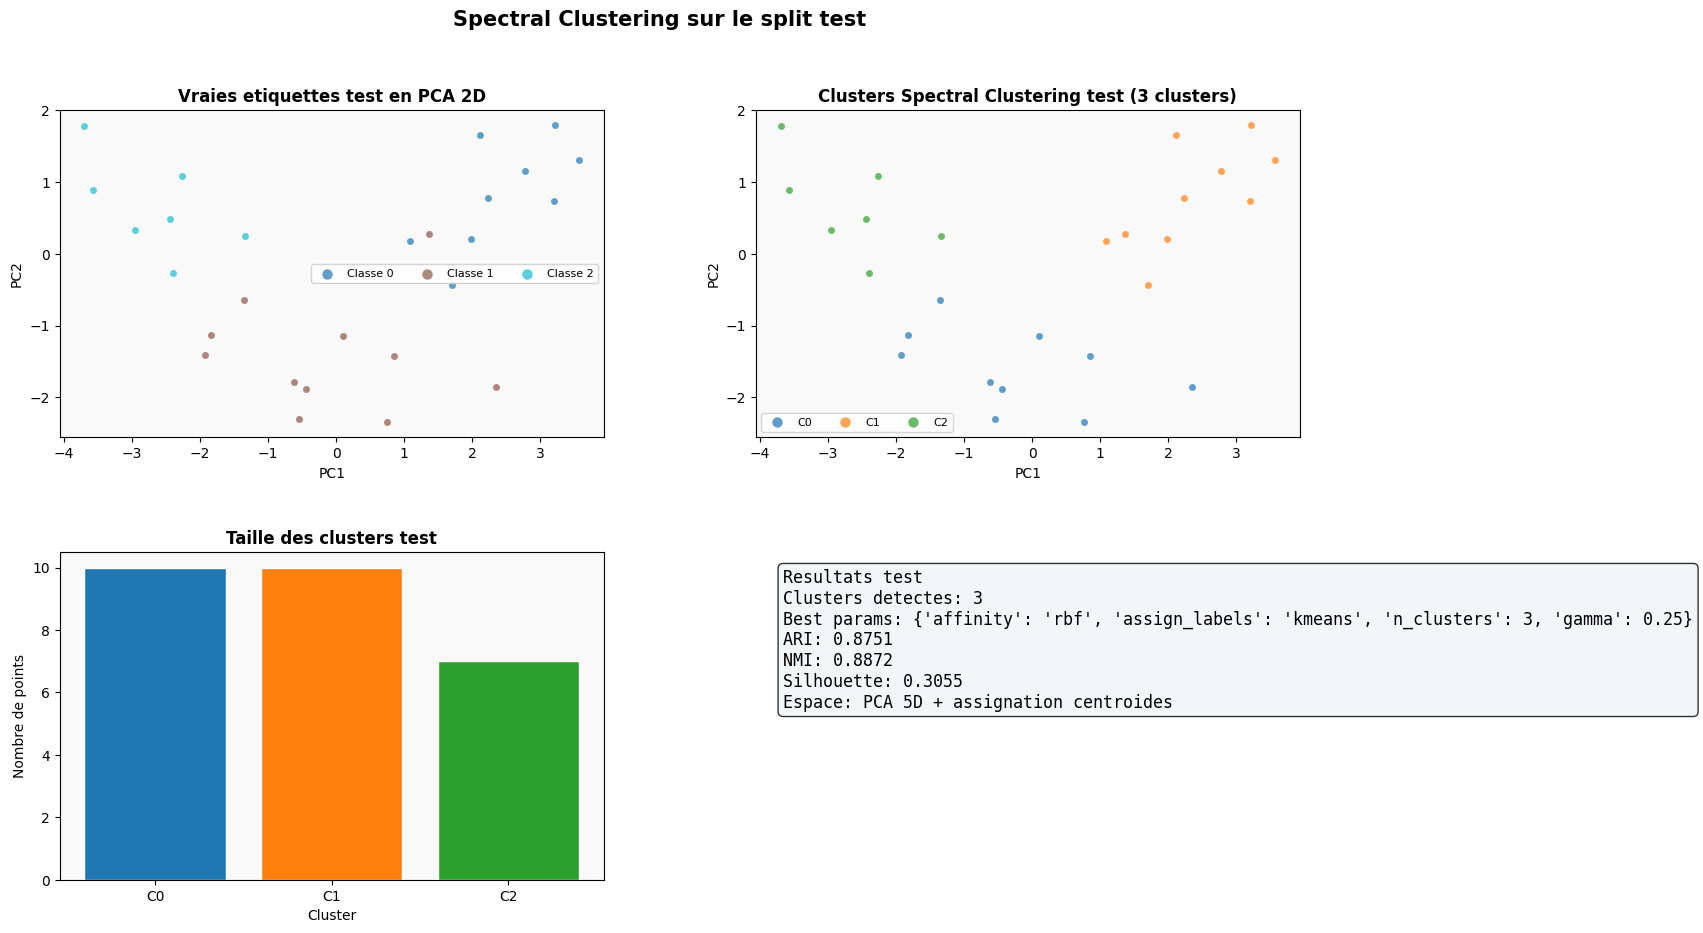

In [5]:
# Visualisation des resultats du split test
if 'labels_test' not in globals():
    print('Les labels du test ne sont pas encore calcules. Execute d abord la cellule de test final.')
else:
    cluster_ids_test, cluster_sizes_test = np.unique(labels_test, return_counts=True)
    n_clusters_test = len(cluster_ids_test)

    palette = plt.cm.tab10(np.linspace(0, 1, max(n_clusters_test, 10)))
    color_map = {cid: palette[i % len(palette)] for i, cid in enumerate(cluster_ids_test)}

    fig = plt.figure(figsize=(16, 10), facecolor='white')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.28)

    ax1 = fig.add_subplot(gs[0, 0])
    for cls in unique_classes:
        mask = y_test == cls
        ax1.scatter(
            X_test_pca2[mask, 0],
            X_test_pca2[mask, 1],
            c=[label_to_color[cls]],
            s=25,
            alpha=0.7,
            linewidths=0,
            label=f'Classe {cls}',
        )
    ax1.set_title('Vraies etiquettes test en PCA 2D', fontsize=12, fontweight='bold')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_facecolor('#f9f9f9')
    ax1.legend(ncol=3, fontsize=8, markerscale=1.5)

    ax2 = fig.add_subplot(gs[0, 1])
    for cid in cluster_ids_test:
        mask = labels_test == cid
        ax2.scatter(
            X_test_pca2[mask, 0],
            X_test_pca2[mask, 1],
            c=[color_map[cid]],
            s=25,
            alpha=0.7,
            linewidths=0,
            label=f'C{cid}',
        )
    ax2.set_title(f'Clusters Spectral Clustering test ({n_clusters_test} clusters)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_facecolor('#f9f9f9')
    ax2.legend(ncol=3, fontsize=8, markerscale=1.5)

    ax3 = fig.add_subplot(gs[1, 0])
    bar_colors = [color_map[cid] for cid in cluster_ids_test]
    ax3.bar([f'C{cid}' for cid in cluster_ids_test], cluster_sizes_test, color=bar_colors, edgecolor='white')
    ax3.set_title('Taille des clusters test', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Cluster')
    ax3.set_ylabel('Nombre de points')
    ax3.set_facecolor('#f9f9f9')

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    metrics_text = (
        f"Resultats test\n"
        f"Clusters detectes: {n_clusters_test}\n"
        f"Best params: {best_params}\n"
        f"ARI: {test_metrics['ari']:.4f}\n"
        f"NMI: {test_metrics['nmi']:.4f}\n"
        f"Silhouette: {test_metrics['silhouette']:.4f}\n"
        f"Espace: PCA 5D + assignation centroides"
    )
    ax4.text(
        0.05,
        0.95,
        metrics_text,
        transform=ax4.transAxes,
        fontsize=12,
        verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8),
    )
    ax4.set_facecolor('white')

    plt.suptitle('Spectral Clustering sur le split test', fontsize=15, fontweight='bold')
    plt.show()